# MBH TDI on the fly (time domain) Tutorial

This tutorial demonstrates `bbhx.mbhtdionfly.MBHTDIonFly`: generating massive-black-hole-binary TDI observables directly in the **time domain**, without an intermediate Fourier transform.

The pipeline has two stages:

1. A time-domain mode generator — [phentax](https://github.com/asantini29/phentax)'s `IMRPhenomTHM` — produces per-mode amplitude and phase on an adaptive time grid.
2. Those splines are fed through the LISA TDI-on-the-fly response (`lisatools.response.tdionfly.TDTDIonTheFly`) to produce the TDI channels.

**Requirements:** `phentax` is not on PyPI. Install it with the `phentax` extra (`pip install 'bbhx[phentax]'`) or directly via `pip install git+https://github.com/asantini29/phentax.git`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from lisaconstants import ASTRONOMICAL_YEAR
from lisatools.detector import EqualArmlengthOrbits
from lisatools.response.tdiconfig import TDIConfig
from phentax.waveform import IMRPhenomTHM

from bbhx.mbhtdionfly import MBHTDIonFly

## Build the waveform generator

`IMRPhenomTHM` produces the (2,2) mode plus the requested higher harmonics in amplitude/phase form. With `coarse_grain=True` the waveform is sampled on an adaptive grid that is dense near merger and sparse during the early inspiral.

In [2]:
Tobs = ASTRONOMICAL_YEAR / 12  # one month
dt = 2.5  # data cadence (sec)
tol = 1e-12  # root-finding tolerance

wave_gen = IMRPhenomTHM(
    higher_modes=[21, 33, 44],
    include_negative_modes=True,  # negative-m modes produced by symmetry
    t_low_fit=True,  # use a fit to seed the t(f) root finder
    coarse_grain=True,
    atol=tol,
    rtol=tol,
    T=Tobs,
)

## Build the TDI-on-the-fly generator

`MBHTDIonFly` combines the waveform generator with orbits and a TDI configuration. The backend (CPU / CUDA) is chosen **at instantiation** via `force_backend` — never per call.

In [3]:
orbits = EqualArmlengthOrbits(force_backend="cpu")
tdi_config = TDIConfig("2nd generation")
t0 = 0.0  # reference time offset (sec)

mbh_tdi_fly_gen = MBHTDIonFly(
    wave_gen,
    orbits,
    tdi_config,
    dt,
    Tobs,
    t0,
    force_backend="cpu",  # or "cuda12x" / "gpu" on a CUDA machine
)

## Generate TDI observables

Calling the generator with source parameters returns a spline-backed TDI output object. Passing `upsample_t_arr` instead evaluates the TDI channels on a uniform grid; `combine=True` sums over modes.

In [4]:
params = dict(
    m1=2.0e6,  # primary mass (solar masses)
    m2=8.0e5,  # secondary mass (solar masses)
    s1z=0.3,  # primary aligned spin
    s2z=0.1,  # secondary aligned spin
    distance=3.0e4,  # luminosity distance
    phi_ref=1.2,  # reference phase
    inclination=0.7,
    ra=1.0,  # right ascension (rad)
    dec=0.3,  # declination (rad)
    psi=0.5,  # polarization angle (rad)
)
t_merge = 2.0e6  # merger time inside the observation window (sec)

# spline-backed output (one entry per mode)
tdifly_output = mbh_tdi_fly_gen(**params, t_merge=t_merge)
print("spline time range:", tdifly_output.t_arr.min(), "-", tdifly_output.t_arr.max(), "sec")

/Users/mkatz/Research/lisa_sprint_2026/GPUBackendTools/src/gpubackendtools/interpolate.py:151: RuntimeWarning: invalid value encountered in log10
  elif self.xp.allclose((_diff := self.xp.diff(self.xp.log10(self.x), axis=-1)), _diff[..., 0][..., None]):


spline time range: 292121.6189120689 - 2003414.0071090711 sec


In [5]:
# evaluate on the uniform data grid, summing the modes
upsample_t_arr = np.arange(int(Tobs / dt)) * dt
tdi_channels = mbh_tdi_fly_gen(
    **params, t_merge=t_merge, upsample_t_arr=upsample_t_arr, combine=True
)
print("TDI output shape (channels, samples):", tdi_channels.shape)

/Users/mkatz/Research/lisa_sprint_2026/GPUBackendTools/src/gpubackendtools/interpolate.py:151: RuntimeWarning: invalid value encountered in log10
  elif self.xp.allclose((_diff := self.xp.diff(self.xp.log10(self.x), axis=-1)), _diff[..., 0][..., None]):


TDI output shape (channels, samples): (3, 1051938)


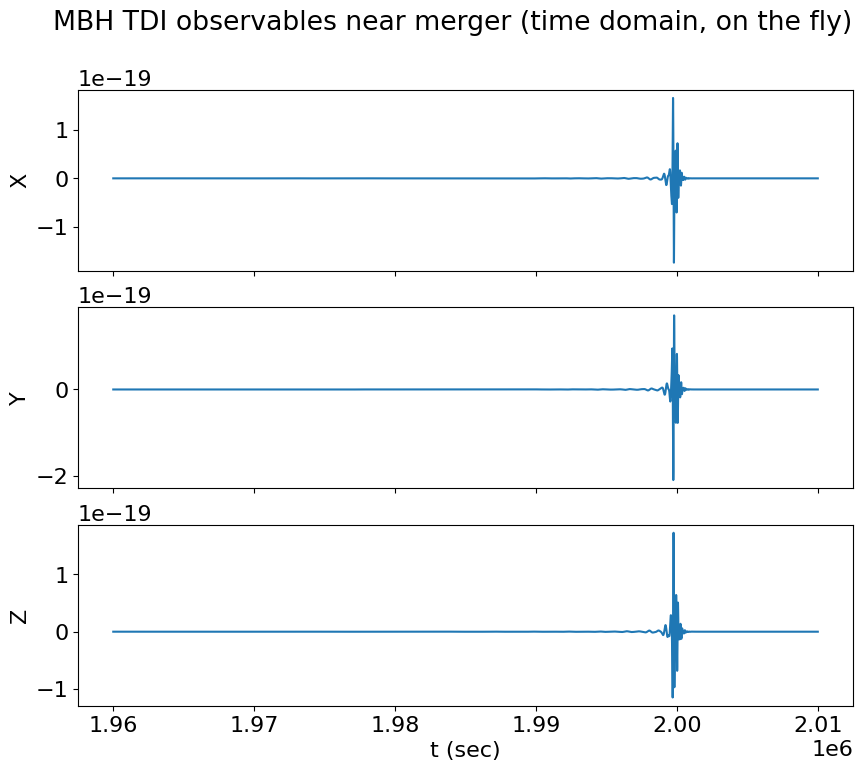

In [6]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))
window = (upsample_t_arr > t_merge - 4e4) & (upsample_t_arr < t_merge + 1e4)
for i, (ax, label) in enumerate(zip(axes, ["X", "Y", "Z"])):
    ax.plot(upsample_t_arr[window], tdi_channels[i, window])
    ax.set_ylabel(label)
axes[-1].set_xlabel("t (sec)")
fig.suptitle("MBH TDI observables near merger (time domain, on the fly)")
plt.show()

## Notes

- The per-mode spline output (`upsample_t_arr=None`) is useful when you want to evaluate the same waveform on several time grids — e.g. inside a sampler — without regenerating the modes.
- On a CUDA machine, pass `force_backend="cuda12x"` (or `"gpu"`) at instantiation and the mode splines + TDI evaluation run on the GPU.
- A buffer at each end of the adaptive grid is discarded before TDI evaluation so the orbit/delay splines stay in range.